In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout,Input,Conv2D,MaxPool2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


In [2]:
(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
no_of_train_img=x_train.shape[0]
no_of_test_img=x_test.shape[0]

x_train=x_train.reshape(no_of_train_img,28,28,1)
x_test=x_test.reshape(no_of_test_img,28,28,1)
input_shape=(28,28,1)
x_test=x_test.astype('float32')
x_train=x_train.astype('float32')

x_train /=255
x_test /=255

In [4]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

In [5]:
model=Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=keras.optimizers.Adadelta(),metrics=['accuracy'])

In [7]:
history=model.fit(x_train,y_train,epochs=10,validation_split=0.2,batch_size=32)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 140s 92ms/step - accuracy: 0.1801 - loss: 2.2677 - val_accuracy: 0.4837 - val_loss: 2.2016
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 135s 90ms/step - accuracy: 0.3864 - loss: 2.1404 - val_accuracy: 0.6561 - val_loss: 2.0227
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 140s 89ms/step - accuracy: 0.5036 - loss: 1.9358 - val_accuracy: 0.7280 - val_loss: 1.7463
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 134s 89ms/step - accuracy: 0.5780 - loss: 1.6628 - val_accuracy: 0.7669 - val_loss: 1.4152
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 133s 88ms/step - accuracy: 0.6225 - loss: 1.3975 - val_accuracy: 0.7928 - val_loss: 1.1198
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 145s 90ms/step - accuracy: 0.6647 - loss: 1.1824 - val_accuracy: 0.8096 - val_loss: 0.9044
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 133s 88ms/step - accuracy: 0.6956 - loss: 1.0336 - val_accuracy: 0.8251 - val_loss: 0.7614
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 143s 89ms/step - accuracy: 

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8624 - loss: 0.5489
Test Loss: 0.5489276647567749
Test Accuracy: 0.8623999953269958


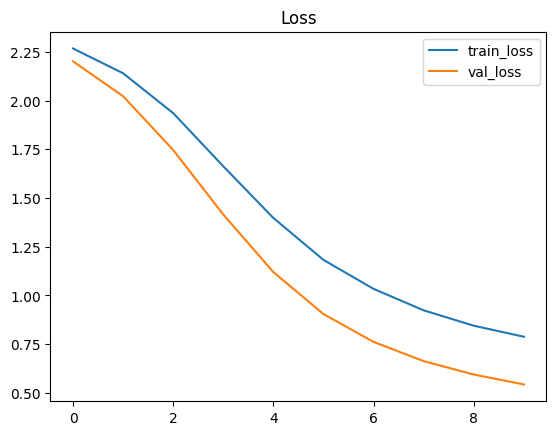

In [9]:
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

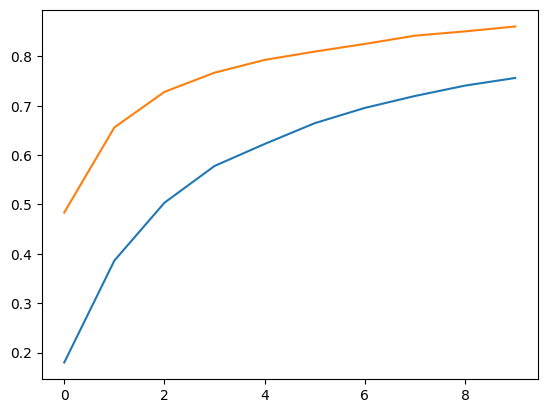

In [10]:
plt.plot(history.history['accuracy'],label='train_acc')
plt.plot(history.history['val_accuracy'],label='val_acc')

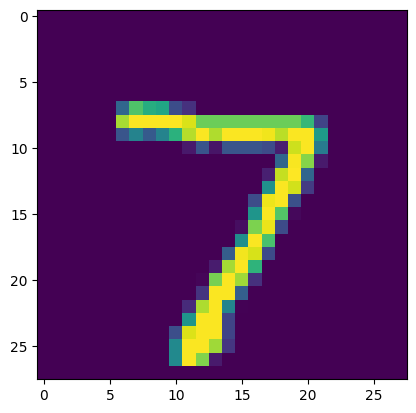

In [11]:
plt.imshow(x_test[0])

In [12]:
model.predict(x_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


array([7])